In [1]:
#librerias 
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


In [2]:
df = pd.read_parquet("data/listings_clean.parquet")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city,log_price
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas",4.584967
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas",5.081404
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas",3.663562
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas",4.983607
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas",4.077537


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76246 entries, 0 to 76245
Data columns (total 81 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            76246 non-null  float64
 1   listing_url                                   76246 non-null  str    
 2   scrape_id                                     76246 non-null  float64
 3   last_scraped                                  76246 non-null  str    
 4   source                                        76246 non-null  str    
 5   name                                          76246 non-null  str    
 6   description                                   76246 non-null  str    
 7   neighborhood_overview                         76246 non-null  str    
 8   picture_url                                   76246 non-null  str    
 9   host_id                                       76246 non-null  int32  
 1

In [4]:
#variables numericas 
df_numeric = df.select_dtypes(include=['int64', 'int32', 'float64'])

In [5]:
# Variable objetivo
y = df_numeric['price']

# Variables predictoras
X = df_numeric.drop(columns=['price'])

In [6]:
X = df_numeric.drop(columns=['price', 'log_price'])


In [7]:
#Train test  datos en entremamiento 80% y prueba 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
#arbol de regresion sin limite de profundidad 
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

este modelo  de árbol de regresión, no tiene restricciones en su profundidad, lo que permite capturar relaciones complejas entre las variables, con el objetivo de establecer una línea base para posteriormente poder comparar con versiones optimizadas. 

In [9]:
#predicciones del conjunto de prueba 

y_pred = model.predict(X_test)


In [10]:
#Evaluaciones 
#metricas de evaluacion
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
#resultados 
print("RMSE:", rmse)
print("R2:", r2)

RMSE: 1852.1636588709591
R2: 0.8158507536415964


El valor de R² indica que el modelo logra explicar aproximadamente el 81.59% de la variabilidad del precio, lo cual representa un buen desempeño inicial. Sin embargo, el error RMSE muestra que aún existen desviaciones considerables en las predicciones.

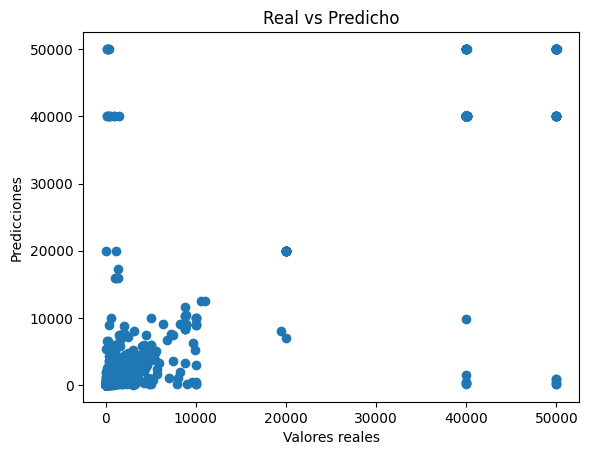

In [11]:
#grafica de valores reales vs predichos 
plt.scatter(y_test, y_pred)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Real vs Predicho")
plt.show()

Idealmente, los puntos deberían alinearse sobre una línea diagonal, lo que indicaría predicciones perfectas. Sin embargo, se observa una alta dispersión en los datos.

El modelo presenta mejor desempeño en valores bajos del precio, mientras que en valores altos muestra mayor variabilidad y errores significativos. Además, existen casos donde el modelo subestima considerablemente el precio.

Esto sugiere que el modelo no generaliza completamente bien y podría estar sobreajustando los datos, ya que no se ha limitado la profundidad del árbol.

In [12]:
# Crear variable respuesta: Económica / Intermedia / Cara

q1 = y.quantile(1/3)
q2 = y.quantile(2/3)

print("Límites de las categorías:")
print(f"Económica: price <= {q1:.2f}")
print(f"Intermedia: {q1:.2f} < price <= {q2:.2f}")
print(f"Cara: price > {q2:.2f}")

y_class = pd.cut(
    y,
    bins=[-np.inf, q1, q2, np.inf],
    labels=["Económica", "Intermedia", "Cara"],
    include_lowest=True
)

print("\nCantidad de registros por clase:")
print(y_class.value_counts())

print("\nPorcentaje por clase:")
print((y_class.value_counts(normalize=True) * 100).round(2))

Límites de las categorías:
Económica: price <= 143.00
Intermedia: 143.00 < price <= 268.00
Cara: price > 268.00

Cantidad de registros por clase:
price
Económica     25689
Cara          25404
Intermedia    25153
Name: count, dtype: int64

Porcentaje por clase:
price
Económica     33.69
Cara          33.32
Intermedia    32.99
Name: proportion, dtype: float64


In [13]:
X_train_class = X.loc[X_train.index].copy()
X_test_class  = X.loc[X_test.index].copy()

y_train_class = y_class.loc[X_train.index].copy()
y_test_class  = y_class.loc[X_test.index].copy()

print("Shapes:")
print("X_train_class:", X_train_class.shape)
print("X_test_class:", X_test_class.shape)
print("y_train_class:", y_train_class.shape)
print("y_test_class:", y_test_class.shape)

Shapes:
X_train_class: (60996, 42)
X_test_class: (15250, 42)
y_train_class: (60996,)
y_test_class: (15250,)


In [14]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_class, y_train_class)

# Predicciones
y_pred_class = clf.predict(X_test_class)

In [15]:
accuracy = accuracy_score(y_test_class, y_pred_class)

print(f"Accuracy del árbol de clasificación: {accuracy:.4f}\n")

print("Reporte de clasificación:")
print(classification_report(y_test_class, y_pred_class))

Accuracy del árbol de clasificación: 0.8746

Reporte de clasificación:
              precision    recall  f1-score   support

        Cara       0.88      0.88      0.88      5051
   Económica       0.91      0.90      0.91      5085
  Intermedia       0.83      0.84      0.84      5114

    accuracy                           0.87     15250
   macro avg       0.87      0.87      0.87     15250
weighted avg       0.87      0.87      0.87     15250



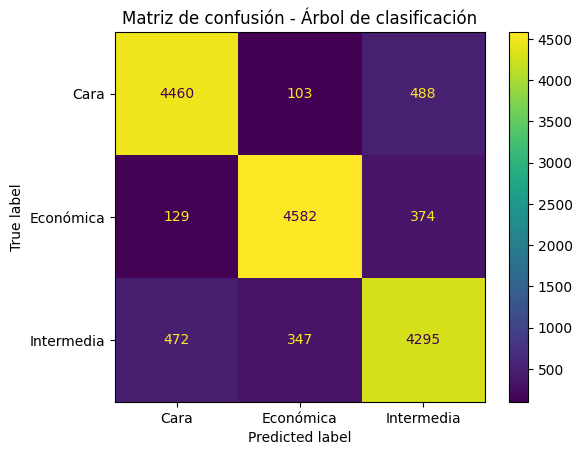

In [16]:
cm = confusion_matrix(y_test_class, y_pred_class, labels=clf.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.title("Matriz de confusión - Árbol de clasificación")
plt.show()

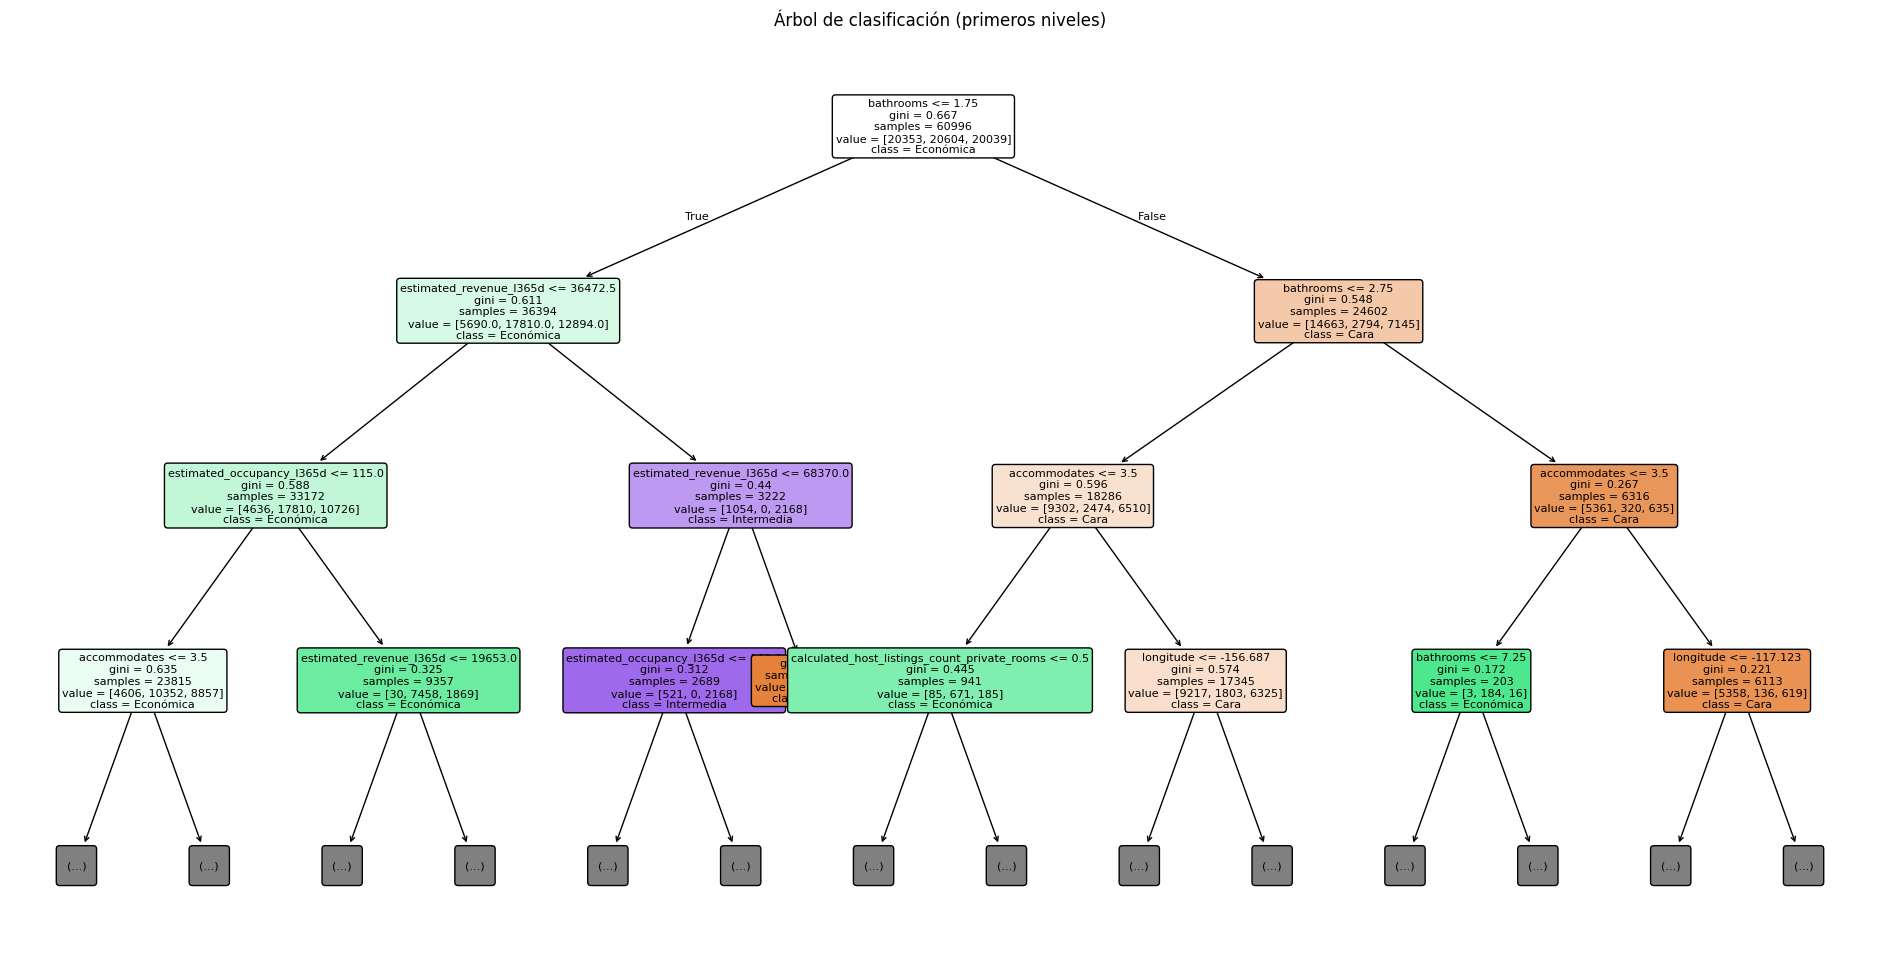

In [17]:
# Gráfica del árbol
plt.figure(figsize=(24, 12))
plot_tree(
    clf,
    feature_names=X_train_class.columns,
    class_names=clf.classes_,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)
plt.title("Árbol de clasificación (primeros niveles)")
plt.show()

In [18]:
resultados_clasificacion = pd.DataFrame({
    "Real": y_test_class.values,
    "Predicho": y_pred_class
})

print(resultados_clasificacion.head(15))

errores = resultados_clasificacion[resultados_clasificacion["Real"] != resultados_clasificacion["Predicho"]]
print(f"\nCantidad de errores: {len(errores)}")
print("\nErrores por combinación:")
print(pd.crosstab(errores["Real"], errores["Predicho"]))

          Real    Predicho
0   Intermedia  Intermedia
1         Cara        Cara
2    Económica   Económica
3    Económica   Económica
4   Intermedia  Intermedia
5         Cara  Intermedia
6   Intermedia   Económica
7   Intermedia   Económica
8    Económica   Económica
9    Económica   Económica
10        Cara  Intermedia
11   Económica   Económica
12  Intermedia   Económica
13  Intermedia  Intermedia
14  Intermedia  Intermedia

Cantidad de errores: 1913

Errores por combinación:
Predicho    Cara  Económica  Intermedia
Real                                   
Económica    129          0         374
Intermedia   472        347           0
Cara           0        103         488
